In [4]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR DATA SOURCE,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT MAY DIFFER FROM OTHER PYTHON ENVIRONMENTS.

print("✅ Data source import complete: Collection of Reddit Scraping on Income Tax")
print("📘 Description: This dataset contains Reddit posts and comments related to discussions about Income Tax.")


✅ Data source import complete: Collection of Reddit Scraping on Income Tax
📘 Description: This dataset contains Reddit posts and comments related to discussions about Income Tax.


In [26]:
# For Google Colab or any Jupyter notebook environment:
import pandas as pd

# Step 1: Upload your Excel file (run this cell and choose your file when prompted)
from google.colab import files
uploaded = files.upload()  # Allows you to select and upload your Excel file

# Step 2: Read the uploaded Excel file
excel_filename = list(uploaded.keys())[0]  # Gets the uploaded file name
df = pd.read_excel(excel_filename)  # Loads the Excel file

# Step 3: Display the first 5 rows
print("\nOriginal Data:")
display(df.head(5))


Saving preprocessed_output.xlsx to preprocessed_output.xlsx

Original Data:


,Post ID,Post Title,Comment ID,Author,Created At,Body,preprocessed_text
0,j0zphm,Megathread: Long-Concealed Records Show Presid...,g6w92rt,meta_perspective,2020-09-28 04:00:35,"SPICY:\n\n>In 2012, he took out a $100 million...",spicy take million mortgage commercial space t...
1,j0zphm,Megathread: Long-Concealed Records Show Presid...,g6w81gj,tobiastheanalrapist,2020-09-28 03:51:36,Federal income taxes paid in 2017 (jointly wit...,federal income tax pay jointly spouse joe bide...
2,j0zphm,Megathread: Long-Concealed Records Show Presid...,g6w6jl0,Dooraven,2020-09-28 03:38:16,"> To me, the most alarming tidbit in the @nyti...",alarm tidbit nytimes story bill dubious refund...
3,j0zphm,Megathread: Long-Concealed Records Show Presid...,g6w5dci,AwesomeBrainPowers,2020-09-28 03:27:47,>\t[Our latest findings build on our previous ...,late finding build previous report president ’...
4,j0zphm,Megathread: Long-Concealed Records Show Presid...,g6w75h1,matt_on_the_internet,2020-09-28 03:43:35,Wait I feel like all of the revelations are dr...,wait feel like revelation drown important one ...


In [27]:
import os
print(os.listdir('/content/'))

['.config', 'preprocessed_output.xlsx', 'sample_data']


## Project Overview

In [6]:
pip install pandas textblob openpyxl


In [28]:
import os
import pandas as pd
from textblob import TextBlob

# Check current directory and files
print("Current Directory:", os.getcwd())
print("Files in Directory:", os.listdir())

# Load Excel File (uploaded to notebook directory)
file_path = '/content/preprocessed_output.xlsx'  # Make sure the file is uploaded here

if os.path.basename(file_path) in os.listdir():
    df = pd.read_excel(file_path)
    print("✅ Dataset Loaded Successfully!")
    print(f"Total Rows: {len(df)}\n")
else:
    raise FileNotFoundError(f"File '{file_path}' not found in current directory.")

# Check Columns
print("🔹 First 5 Rows:")
print(df.head(), "\n")

print("🔍 Missing Values in Each Column:")
print(df.isnull().sum(), "\n")

# Perform Sentiment Analysis
text_column = 'preprocessed_text'  # Change if actual column name differ

def get_sentiment(text):
    analysis = TextBlob(str(text))
    polarity = analysis.sentiment.polarity
    if polarity > 0:
        sentiment = 'positive'
    elif polarity == 0:
        sentiment = 'neutral'
    else:
        sentiment = 'negative'
    return pd.Series([sentiment, polarity])

df[['sentiment', 'polarity']] = df[text_column].apply(get_sentiment)

# Sentiment Overview
print("💬 Unique Sentiment Values:")
print(df['sentiment'].unique(), "\n")

print("📊 Sentiment Distribution:")
print(df['sentiment'].value_counts(), "\n")

# Encode Sentiment Values
mapping = {'negative': 0, 'neutral': 2, 'positive': 1}
df['sentiment_encoded'] = df['sentiment'].map(mapping)

print("🔠 Sentiment Encoding Mapping:")
for key, value in mapping.items():
    print(f"{key} → {value}")
print()

# Shuffle Dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("🔀 DataFrame Shuffled Successfully!\n")

# Show Encoded Data Sample
print("✅ Data After Encoding:")
print(df.head(), "\n")

# Save Encoded File
output_path = 'encoded_sentiment_80000.xlsx'  # Output file
df.to_excel(output_path, index=False)

print(f"💾 Full Encoded Dataset Saved as: {output_path}")
print(f"📈 Total Reviews Processed: {len(df)}\n")

print("📊 Encoded Sentiment Distribution:")
print(df['sentiment_encoded'].value_counts())


Current Directory: /content
Files in Directory: ['.config', 'preprocessed_output.xlsx', 'sample_data']
✅ Dataset Loaded Successfully!
Total Rows: 82128

🔹 First 5 Rows:
  Post ID                                         Post Title Comment ID  \
0  j0zphm  Megathread: Long-Concealed Records Show Presid...    g6w92rt   
1  j0zphm  Megathread: Long-Concealed Records Show Presid...    g6w81gj   
2  j0zphm  Megathread: Long-Concealed Records Show Presid...    g6w6jl0   
3  j0zphm  Megathread: Long-Concealed Records Show Presid...    g6w5dci   
4  j0zphm  Megathread: Long-Concealed Records Show Presid...    g6w75h1   

                 Author           Created At  \
0      meta_perspective  2020-09-28 04:00:35   
1   tobiastheanalrapist  2020-09-28 03:51:36   
2              Dooraven  2020-09-28 03:38:16   
3    AwesomeBrainPowers  2020-09-28 03:27:47   
4  matt_on_the_internet  2020-09-28 03:43:35   

                                                Body  \
0  SPICY:\n\n>In 2012, he took out 

## Data Preprocessing (Tokenization + Stopwords removal + Lemmatization)

## Feature Extraction & Model NaveBayes Prediction

In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# Load the DataFrame with encoded sentiment
file_path = '/content/encoded_sentiment_80000.xlsx'
df = pd.read_excel(file_path)

# Fill missing values in 'preprocessed_text' with empty strings
df['preprocessed_text'] = df['preprocessed_text'].fillna('')

#features
X=df['preprocessed_text']

#target
y=df['sentiment_encoded']


#convert text into numerical features
vectorizer=CountVectorizer()
X_counts=vectorizer.fit_transform(df['preprocessed_text'])

#Train,test and split data
X_train,X_test,y_train,y_test=train_test_split(X_counts,y,test_size=0.3,random_state=42)

#nave bayes model
model=MultinomialNB()
model.fit(X_train,y_train)

#prediction
y_pred=model.predict(X_test)
print("===========Model Nave Bayes=============")
print("News is predicted as : ",y_pred[:10])

#metrics evaluation
nb_acc=accuracy_score(y_test, y_pred)
nb_pre=precision_score(y_test, y_pred, average='weighted')
nb_rec=recall_score(y_test, y_pred, average='weighted')
nb_f1=f1_score(y_test, y_pred, average='weighted')
nb_cm=confusion_matrix(y_test, y_pred)

try:
    nb_roc = roc_auc_score(y_test, y_pred, average='macro', multi_class='ovo')
except Exception as e:
    nb_roc = f"Error: {e}"


print("==========================================")
print("============Model Performance=============")
print("Accuracy:",nb_acc)
print("Precision:",nb_pre)
print("Recall:",nb_rec)
print("F1-Score:",nb_f1)
print("Confusion Matrix:\n",nb_cm)
print("ROC-AUC:",nb_roc)

===========Model Nave Bayes=============
News is predicted as :  [1 1 1 1 1 1 1 0 1 1]
============Model Performance=============
Accuracy: 0.647753561427006
Precision: 0.7152320351847681
Recall: 0.647753561427006
F1-Score: 0.6075920792372554
Confusion Matrix:
 [[ 2714  2720    85]
 [  595 11539   134]
 [  314  4831  1707]]
ROC-AUC: Error: axis 1 is out of bounds for array of dimension 1


## Logistic Regression Prediction

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

#logistic regression
reg=LogisticRegression(max_iter=1000)
reg.fit(X_train,y_train)
reg_pred=reg.predict(X_test)

#predictions
print("===========Model Logistic Regression=============")
print("News is predicted as : ",reg_pred[:10])

#metrics evaluation
lr_acc=accuracy_score(y_test, reg_pred)
lr_pre=precision_score(y_test, reg_pred, average='weighted')
lr_rec=recall_score(y_test, reg_pred, average='weighted')
lr_f1=f1_score(y_test, reg_pred, average='weighted')
lr_cm=confusion_matrix(y_test, reg_pred)

try:
    lr_roc = roc_auc_score(y_test, reg_pred, average='macro', multi_class='ovo')
except Exception as e:
    lr_roc = f"Error: {e}"


print("==========================================")
print("============Model Performance=============")
print("Accuracy:",lr_acc)
print("Precision:",lr_pre)
print("Recall:",lr_rec)
print("F1-Score:",lr_f1)
print("Confusion Matrix:\n",lr_cm)
print("ROC-AUC:",lr_roc)

===========Model Logistic Regression=============
News is predicted as :  [0 2 0 1 2 1 0 2 1 0]
============Model Performance=============
Accuracy: 0.9378221518730468
Precision: 0.9376667710734699
Recall: 0.9378221518730468
F1-Score: 0.9373806637723353
Confusion Matrix:
 [[ 4750   489   280]
 [  352 11685   231]
 [   65   115  6672]]
ROC-AUC: Error: axis 1 is out of bounds for array of dimension 1


## SVM Predictions

In [4]:
pip install pandas openpyxl


In [7]:
import pandas as pd

# Change "your_file.xlsx" to your filename
df = pd.read_excel("preprocessed_output.xlsx")


In [10]:
corpus = df['preprocessed_text'].tolist()


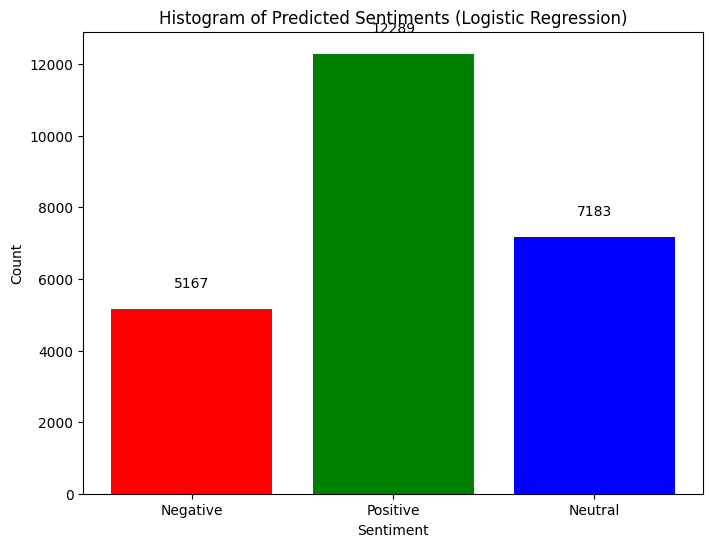

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

# Ensure the DataFrame is loaded and preprocessed text is available
file_path = '/content/encoded_sentiment_80000.xlsx'
df = pd.read_excel(file_path)
df['preprocessed_text'] = df['preprocessed_text'].fillna('')

# Features and target
X = df['preprocessed_text']
y = df['sentiment_encoded']

# Convert text into numerical features
vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(X)

# Train, test and split data
X_train, X_test, y_train, y_test = train_test_split(X_counts, y, test_size=0.3, random_state=42)

# Train Logistic Regression model and get predictions
reg = LogisticRegression(max_iter=1000)
reg.fit(X_train, y_train)
reg_pred = reg.predict(X_test)


# Count sentiment predictions
unique, counts = np.unique(reg_pred, return_counts=True)
sentiment_counts = dict(zip(unique, counts))

# Define mapping from encoded sentiment to label
sentiment_map = {0: 'Negative', 1: 'Positive', 2: 'Neutral'}

# Sort sentiment counts by encoded value for consistent plotting order
sorted_sentiment_counts = {k: sentiment_counts.get(k, 0) for k in sorted(sentiment_map.keys())}
labels = [sentiment_map[k] for k in sorted_sentiment_counts.keys()]
values = list(sorted_sentiment_counts.values())

# Plot histogram of sentiment counts
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values, color=['red', 'green', 'blue']) # Assign colors based on sentiment category
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Histogram of Predicted Sentiments (Logistic Regression)')

# Add counts on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, yval, ha='center', va='bottom') # Adjust vertical offset

plt.show()

## Visualizations

## Confusion Matrix (According to SYM) for Best Model Accuracy

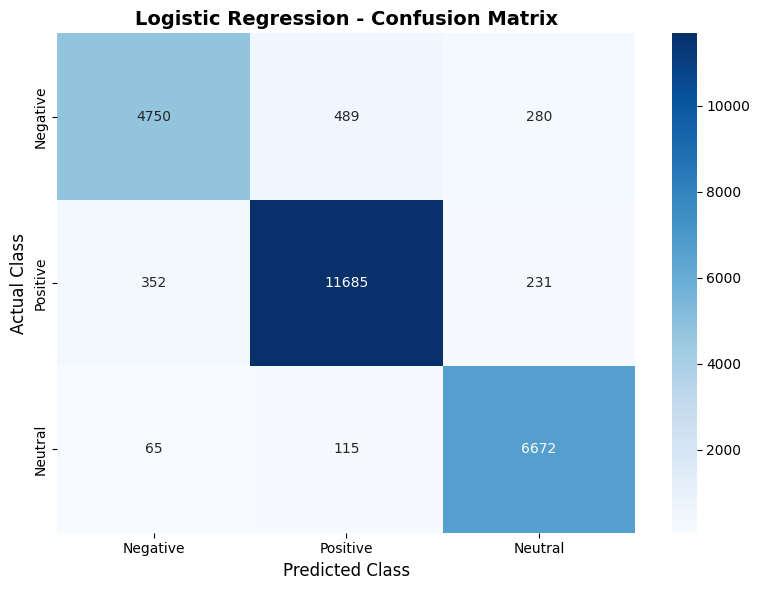

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns # Import seaborn for better visualization
from sklearn.metrics import confusion_matrix
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

# Load the DataFrame with encoded sentiment
file_path = '/content/encoded_sentiment_80000.xlsx'
df = pd.read_excel(file_path)

# Fill missing values in 'preprocessed_text' with empty strings
df['preprocessed_text'] = df['preprocessed_text'].fillna('')

# Features and target
X = df['preprocessed_text']
y = df['sentiment_encoded']

# Convert text into numerical features
vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(X)

# Train, test and split data
X_train, X_test, y_train, y_test = train_test_split(X_counts, y, test_size=0.3, random_state=42)

# Train Logistic Regression model and get predictions
reg = LogisticRegression(max_iter=1000)
reg.fit(X_train, y_train)
reg_pred = reg.predict(X_test)

# Calculate the confusion matrix for the Logistic Regression model
lr_cm = confusion_matrix(y_test, reg_pred)

# Define sentiment labels
sentiment_labels = ['Negative', 'Positive', 'Neutral']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', xticklabels=sentiment_labels, yticklabels=sentiment_labels)
plt.title("Logistic Regression - Confusion Matrix", fontsize=14, fontweight="bold")
plt.ylabel("Actual Class", fontsize=12)
plt.xlabel("Predicted Class", fontsize=12)

plt.tight_layout()
plt.show()

# You can also display the confusion matrix with percentages if preferred
# lr_cm_percent = lr_cm.astype("float") / lr_cm.sum(axis=1)[:, np.newaxis] * 100
# plt.figure(figsize=(8, 6))
# sns.heatmap(lr_cm_percent, annot=True, fmt='.2f', cmap='Blues', xticklabels=sentiment_labels, yticklabels=sentiment_labels)
# plt.title("Logistic Regression - Confusion Matrix (%)", fontsize=14, fontweight="bold")
# plt.ylabel("Actual Class", fontsize=12)
# plt.xlabel("Predicted Class", fontsize=12)
# plt.tight_layout()
# plt.show()

## Wordcloud for Positive/Negative Reviews

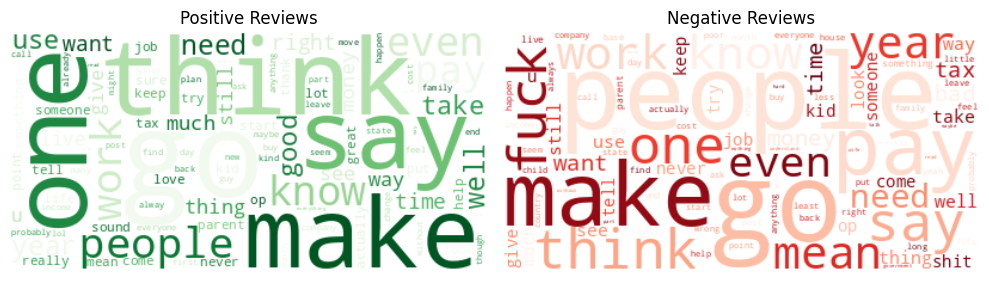

In [15]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Load the DataFrame with sentiment labels
file_path = '/content/encoded_sentiment_80000.xlsx'
df = pd.read_excel(file_path)

# Ensure 'preprocessed_text' column exists and handle missing values
df['preprocessed_text'] = df['preprocessed_text'].fillna('')

# Get positive and negative reviews using the 'sentiment' column
positive_reviews = df[df['sentiment'] == 'positive']['preprocessed_text']
negative_reviews = df[df['sentiment'] == 'negative']['preprocessed_text']

# Create word clouds for positive and negative reviews
# Generate word cloud for positive reviews
positive_wordcloud = WordCloud(colormap='Greens', max_words=100, background_color='white').generate(' '.join(positive_reviews))

# Generate word cloud for negative reviews
negative_wordcloud = WordCloud(colormap='Reds', max_words=100, background_color='white').generate(' '.join(negative_reviews))


# Plot word clouds
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.title('Positive Reviews')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.title('Negative Reviews')
plt.axis('off')

plt.tight_layout()
plt.show()

## Histogram – Review Length Distribution (Positive vs Negative Reviews)

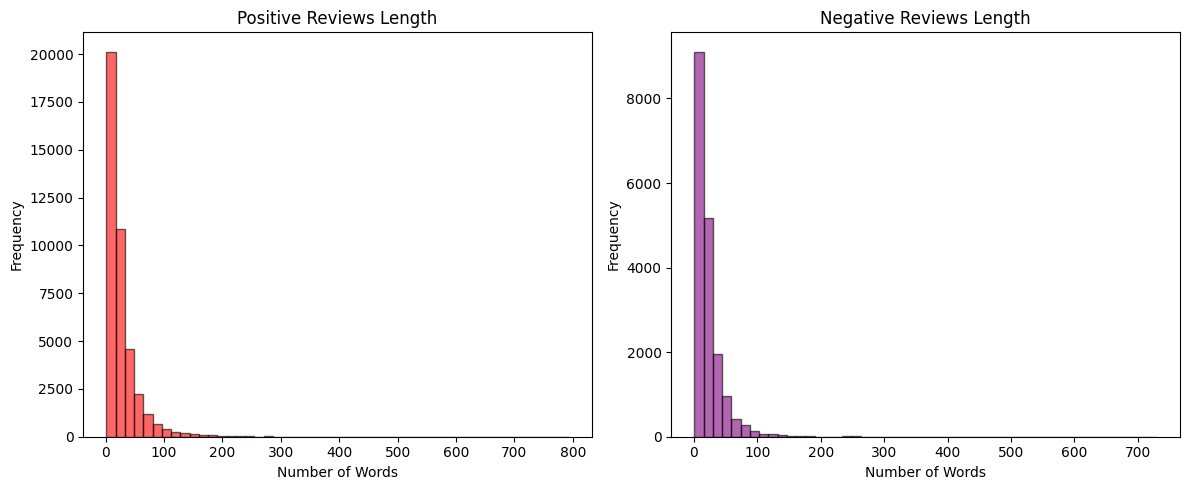

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the DataFrame with encoded sentiment
file_path = '/content/encoded_sentiment_80000.xlsx'
df = pd.read_excel(file_path)

# Ensure 'preprocessed_text' column exists and handle missing values
df['preprocessed_text'] = df['preprocessed_text'].fillna('')


# Calculate review lengths
df['review_length'] = df['preprocessed_text'].apply(lambda x: len(x.split())) #apply() lets you run a function on each element of a column
#for each row of x in text column split the string into words and count them.

# Separate lengths by sentiment (using sentiment_encoded)
pos_lengths = df[df['sentiment_encoded']==1]['review_length']
neg_lengths = df[df['sentiment_encoded']==0]['review_length']

# Plot side-by-side histograms
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.hist(pos_lengths, bins=50, color='red', alpha=0.6, edgecolor='black') # Increased bins for better distribution
plt.title('Positive Reviews Length')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(neg_lengths, bins=50, color='purple', alpha=0.6, edgecolor='black') # Increased bins for better distribution
plt.title('Negative Reviews Length')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Distribution of Review Length vs Word Count Categories

## Histogram

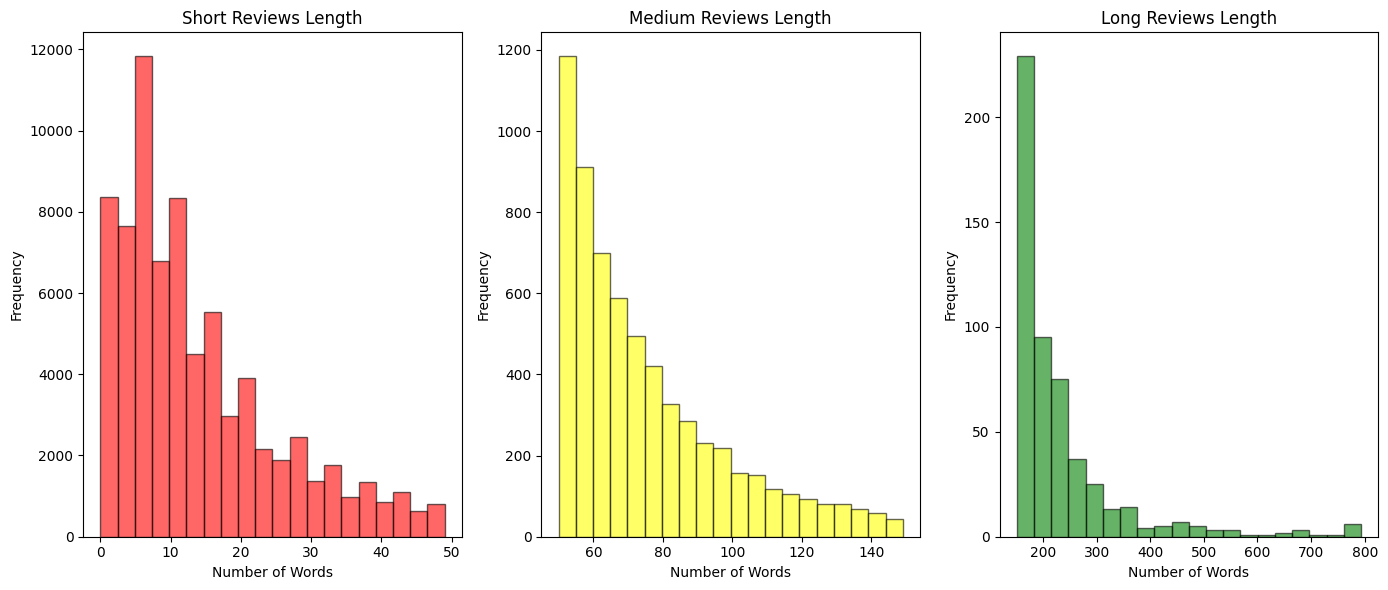

In [17]:
# Calculate review lengths
df['review_length'] = df['preprocessed_text'].apply(lambda x: len(x.split()))
df['short_review'] = df['review_length'].apply(lambda x: True if x < 50 else False)
df['medium_review']= df['review_length'].apply(lambda x: True if x >= 50 and x < 150 else False)
df['long_review'] = df['review_length'].apply(lambda x: True if x > 150 else False)

#subplots for each review
plt.figure(figsize=(14,6))

#subplot for short reviews
plt.subplot(1,3,1)
plt.hist(df[df['short_review'] == True]['review_length'], bins=20, color='red', alpha=0.6, edgecolor='black')
plt.title('Short Reviews Length')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

#subplot for medium reviews
plt.subplot(1,3,2)
plt.hist(df[df['medium_review']==True]['review_length'],bins=20,color='yellow',alpha=0.6,edgecolor='black')
plt.title('Medium Reviews Length')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

#subplot for long reviews
plt.subplot(1,3,3)
plt.hist(df[df['long_review'] == True]['review_length'], bins=20, color='green', alpha=0.6, edgecolor='black')
plt.title('Long Reviews Length')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Bar Chart

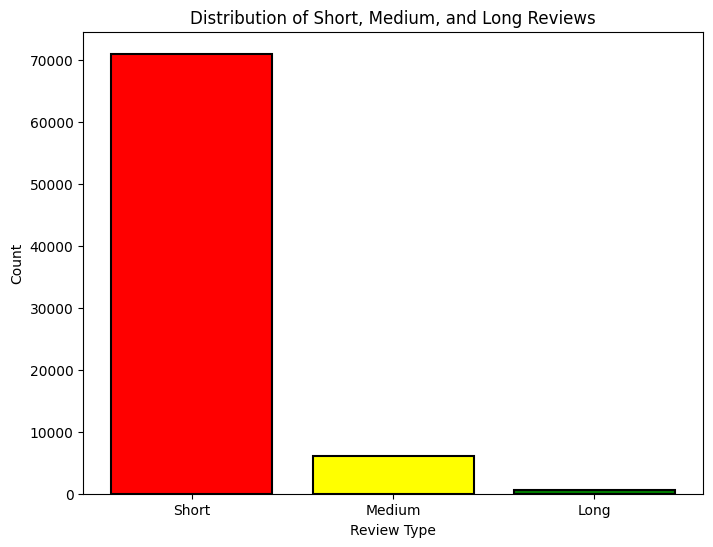

In [18]:
# Review length categories
df['review_length'] = df['preprocessed_text'].apply(lambda x: len(x.split()))
df['review_type'] = pd.cut(df['review_length'],
                           bins=[0, 50, 150, float('inf')],
                           labels=['Short', 'Medium', 'Long'])

# Count values for each category
counts = df['review_type'].value_counts().reindex(['Short', 'Medium', 'Long'])

# Bar chart with border
plt.figure(figsize=(8,6))
bars = plt.bar(counts.index, counts.values,
               color=['red', 'yellow', 'green'],
               edgecolor='black', linewidth=1.5)

plt.title('Distribution of Short, Medium, and Long Reviews')
plt.xlabel('Review Type')
plt.ylabel('Count')
plt.show()

## Submission.csv

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

# Load the DataFrame with encoded sentiment
file_path = '/content/encoded_sentiment_80000.xlsx'
df = pd.read_excel(file_path)

# Fill missing values in 'preprocessed_text' with empty strings
df['preprocessed_text'] = df['preprocessed_text'].fillna('')

# Features and target
X = df['preprocessed_text']
y = df['sentiment_encoded']

# Convert text into numerical features
vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(X)

# Train, test and split data
X_train, X_test, y_train, y_test = train_test_split(X_counts, y, test_size=0.3, random_state=42)

# Train Logistic Regression model and get predictions (ensure reg_pred is available)
reg = LogisticRegression(max_iter=1000)
reg.fit(X_train, y_train)
reg_pred = reg.predict(X_test)

# Map encoded predictions back to original sentiment labels
mapping = {0: 'negative', 1: 'positive', 2: 'neutral'}
sentiment_predictions = [mapping[pred] for pred in reg_pred]

# Save predictions of best model (logistic regression) for submission
submission = pd.DataFrame({
    "id": range(len(sentiment_predictions)),
    "sentiment": sentiment_predictions
})

submission.to_csv("submission.csv", index=False)
print("✅ submission.csv file generated!")

✅ submission.csv file generated!
